### **Imitation Learning on LunarLander**

End-to-end pipeline:

1. **Train a DQN expert** on `LunarLander-v3` until it solves the task (rolling avg ≥ 200).
2. **Collect a database of expert experiences** — roll out the trained DQN for many episodes and store every `(state, action)` pair in NumPy arrays held in memory.
3. **Train a fresh student policy from scratch** by supervised classification on those `(state, action)` pairs — this is **Behavioral Cloning**.
4. **Evaluate** the student greedily and try to reach the official solved threshold of **200**.

Notes on the design:

- The student never sees a reward signal. It only sees expert decisions.
- LunarLander has 8 continuous observation features and 4 discrete actions, so this is a tiny classification problem.
- We store the database in two NumPy arrays: `states` of shape `[N, 8]` and `actions` of shape `[N]`. For larger projects you could swap this for a pandas DataFrame or save to disk.


In [1]:
import random
from collections import deque
from dataclasses import dataclass

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

@dataclass
class Config:
    ENV_NAME: str = "LunarLander-v3"

    # --- DQN expert training ---
    MAX_EPISODES: int = 500
    MAX_STEPS: int = 1000
    REPLAY_SIZE: int = 100_000
    BATCH_SIZE: int = 128
    GAMMA: float = 0.99
    TAU: float = 0.005
    LR: float = 5e-4
    HIDDEN_DIM: int = 128
    EPS_START: float = 1.0
    EPS_END: float = 0.05
    EPS_DECAY: float = 0.99
    START_STEPS: int = 1_000
    ROLLING_WINDOW: int = 20
    SOLVED_REWARD: float = 200.0

    # --- Demonstration database ---
    DEMO_EPISODES: int = 150         # how many expert rollouts to collect
    DEMO_MIN_RETURN: float = 200.0   # only keep episodes where the expert succeeded

    # --- Behavioral Cloning (student) ---
    BC_HIDDEN_DIM: int = 256
    BC_LR: float = 1e-3
    BC_EPOCHS: int = 60
    BC_BATCH_SIZE: int = 256
    BC_VAL_FRACTION: float = 0.1

cfg = Config()
cfg


Device: cuda


Config(ENV_NAME='LunarLander-v3', MAX_EPISODES=500, MAX_STEPS=1000, REPLAY_SIZE=100000, BATCH_SIZE=128, GAMMA=0.99, TAU=0.005, LR=0.0005, HIDDEN_DIM=128, EPS_START=1.0, EPS_END=0.05, EPS_DECAY=0.99, START_STEPS=1000, ROLLING_WINDOW=20, SOLVED_REWARD=200.0, DEMO_EPISODES=150, DEMO_MIN_RETURN=200.0, BC_HIDDEN_DIM=256, BC_LR=0.001, BC_EPOCHS=60, BC_BATCH_SIZE=256, BC_VAL_FRACTION=0.1)

In [3]:
env = gym.make(cfg.ENV_NAME)
eval_env = gym.make(cfg.ENV_NAME)

state_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

print("State dimension:", state_dim)
print("Number of actions:", n_actions)


State dimension: 8
Number of actions: 4


/home/jaume/_DEVELOPMENT/ML/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


---
#### **Phase 1 — Training the expert with DQN**
---

Replay buffer, Q-network, and agent — the same vanilla DQN as in the standalone notebook.


In [4]:
class ReplayBuffer:
    def __init__(self, max_size):
        self.buffer = deque(maxlen=max_size)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        states = torch.tensor(np.array(states), dtype=torch.float32, device=device)
        actions = torch.tensor(np.array(actions), dtype=torch.long, device=device).unsqueeze(1)
        rewards = torch.tensor(np.array(rewards), dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=device)
        dones = torch.tensor(np.array(dones), dtype=torch.float32, device=device).unsqueeze(1)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


In [5]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, state):
        return self.net(state)


In [6]:
class DQNAgent:
    def __init__(self, state_dim, n_actions, config):
        self.cfg = config
        self.n_actions = n_actions
        self.q = QNetwork(state_dim, n_actions, config.HIDDEN_DIM).to(device)
        self.q_target = QNetwork(state_dim, n_actions, config.HIDDEN_DIM).to(device)
        self.q_target.load_state_dict(self.q.state_dict())
        self.optimizer = optim.Adam(self.q.parameters(), lr=config.LR)
        self.replay_buffer = ReplayBuffer(config.REPLAY_SIZE)
        self.epsilon = config.EPS_START

    def select_action(self, state, evaluate=False):
        if (not evaluate) and (random.random() < self.epsilon):
            return random.randrange(self.n_actions)
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q(state_t)
        return int(q_values.argmax(dim=1).item())

    def decay_epsilon(self):
        self.epsilon = max(self.cfg.EPS_END, self.epsilon * self.cfg.EPS_DECAY)

    def update(self):
        if len(self.replay_buffer) < self.cfg.BATCH_SIZE:
            return None
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.cfg.BATCH_SIZE)
        q_pred = self.q(states).gather(1, actions)
        with torch.no_grad():
            q_next = self.q_target(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + (1 - dones) * self.cfg.GAMMA * q_next
        loss = F.mse_loss(q_pred, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q.parameters(), max_norm=10.0)
        self.optimizer.step()
        for src, tgt in zip(self.q.parameters(), self.q_target.parameters()):
            tgt.data.copy_(self.cfg.TAU * src.data + (1.0 - self.cfg.TAU) * tgt.data)
        return loss.item()


In [7]:
def evaluate_policy_fn(select_action_fn, env, episodes=5):
    """Generic greedy evaluator. select_action_fn takes a state and returns an int action."""
    rewards = []
    for _ in range(episodes):
        state, _ = env.reset()
        total = 0.0
        done = False
        while not done:
            action = select_action_fn(state)
            state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            done = terminated or truncated
        rewards.append(total)
    return float(np.mean(rewards)), float(np.std(rewards))


### **DQN Training**

We stop early as soon as the rolling-20 average passes 200 — that's our trained expert.


In [24]:
%%time
expert = DQNAgent(state_dim, n_actions, cfg)

expert_rewards = []
rolling = deque(maxlen=cfg.ROLLING_WINDOW)
total_steps = 0
expert_solved_at = None

for episode in range(1, cfg.MAX_EPISODES + 1):
    state, _ = env.reset(seed=SEED + episode)
    ep_reward = 0.0

    for step in range(cfg.MAX_STEPS):
        if total_steps < cfg.START_STEPS:
            action = env.action_space.sample()
        else:
            action = expert.select_action(state, evaluate=False)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        expert.replay_buffer.add(state, action, reward, next_state, float(terminated))

        state = next_state
        ep_reward += reward
        total_steps += 1

        if total_steps >= cfg.START_STEPS:
            expert.update()

        if done:
            break

    expert.decay_epsilon()
    expert_rewards.append(ep_reward)
    rolling.append(ep_reward)
    rolling_avg = float(np.mean(rolling))

    if episode % 10 == 0 or episode == 1:
        print(f"Episode {episode:4d} | Reward: {ep_reward:8.2f} | "
              f"Rolling Avg: {rolling_avg:8.2f} | eps: {expert.epsilon:.3f}")

    if rolling_avg >= cfg.SOLVED_REWARD and len(rolling) == cfg.ROLLING_WINDOW:
        expert_solved_at = episode
        print(f"\nExpert solved the env at episode {episode} (rolling avg {rolling_avg:.2f}).")
        break

if expert_solved_at is None:
    print(f"\nExpert finished {cfg.MAX_EPISODES} episodes without crossing 200. "
          f"Final rolling avg: {rolling_avg:.2f}")


Episode    1 | Reward:  -207.57 | Rolling Avg:  -207.57 | eps: 0.990
Episode   10 | Reward:   -76.05 | Rolling Avg:  -172.20 | eps: 0.904
Episode   20 | Reward:   -70.53 | Rolling Avg:  -198.87 | eps: 0.818
Episode   30 | Reward:   -39.59 | Rolling Avg:  -187.62 | eps: 0.740
Episode   40 | Reward:  -110.29 | Rolling Avg:  -128.51 | eps: 0.669
Episode   50 | Reward:   -76.00 | Rolling Avg:  -101.30 | eps: 0.605
Episode   60 | Reward:    -2.79 | Rolling Avg:   -68.92 | eps: 0.547
Episode   70 | Reward:  -175.39 | Rolling Avg:   -37.94 | eps: 0.495
Episode   80 | Reward:  -300.56 | Rolling Avg:   -55.02 | eps: 0.448
Episode   90 | Reward:   -17.88 | Rolling Avg:   -56.04 | eps: 0.405
Episode  100 | Reward:  -123.54 | Rolling Avg:   -44.07 | eps: 0.366
Episode  110 | Reward:   -89.57 | Rolling Avg:   -51.71 | eps: 0.331
Episode  120 | Reward:   109.94 | Rolling Avg:   -23.66 | eps: 0.299
Episode  130 | Reward:   111.34 | Rolling Avg:    44.69 | eps: 0.271
Episode  140 | Reward:   -27.48 | 

In [25]:
# Sanity-check the expert greedily
expert_mean, expert_std = evaluate_policy_fn(
    lambda s: expert.select_action(s, evaluate=True), eval_env, episodes=10
)
print(f"Expert greedy evaluation over 10 episodes: {expert_mean:.2f} ± {expert_std:.2f}")


Expert greedy evaluation over 10 episodes: 242.77 ± 85.70


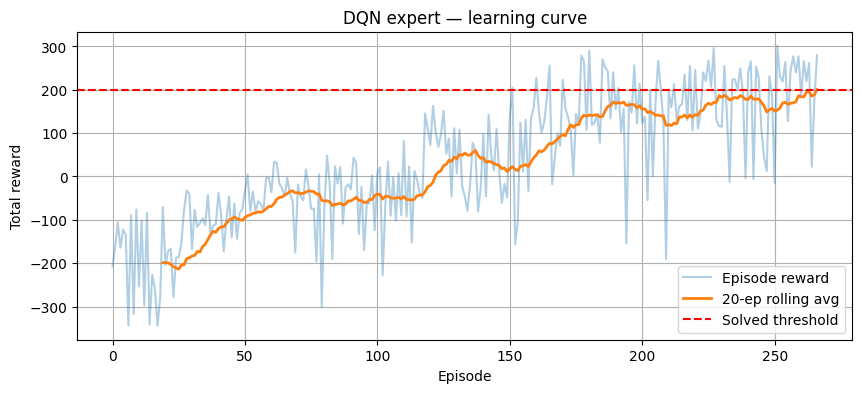

In [26]:
plt.figure(figsize=(10, 4))
plt.plot(expert_rewards, alpha=0.35, label="Episode reward")
if len(expert_rewards) >= cfg.ROLLING_WINDOW:
    roll = np.convolve(expert_rewards, np.ones(cfg.ROLLING_WINDOW) / cfg.ROLLING_WINDOW, mode="valid")
    plt.plot(range(cfg.ROLLING_WINDOW - 1, cfg.ROLLING_WINDOW - 1 + len(roll)),
             roll, label=f"{cfg.ROLLING_WINDOW}-ep rolling avg", linewidth=2)
plt.axhline(cfg.SOLVED_REWARD, color="red", linestyle="--", label="Solved threshold")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("DQN expert — learning curve")
plt.legend()
plt.grid(True)
plt.show()


---
#### **Phase 2 — Build the demonstration database**
---
Roll out the trained DQN greedily for `DEMO_EPISODES` episodes and store every `(state, action)` pair. We accumulate them in plain Python lists and then convert to NumPy at the end. We also build a pandas DataFrame view for convenience and inspection.

**Why greedy?** The DQN's argmax-Q policy is the strongest version of itself — exactly the behavior we want the student to copy.


In [11]:
def collect_demonstrations(expert_agent, env, n_episodes, seed=SEED):
    """Run the expert greedily for n_episodes and return arrays of states and actions."""
    state_list = []
    action_list = []
    episode_returns = []
    episode_ids = []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + 1000 + ep)
        total = 0.0
        done = False
        while not done:
            action = expert_agent.select_action(state, evaluate=True)
            state_list.append(state.astype(np.float32))
            action_list.append(int(action))
            episode_ids.append(ep)

            next_state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            state = next_state
            done = terminated or truncated

        episode_returns.append(total)

    states = np.array(state_list, dtype=np.float32)
    actions = np.array(action_list, dtype=np.int64)
    episode_ids = np.array(episode_ids, dtype=np.int32)
    episode_returns = np.array(episode_returns, dtype=np.float32)
    return states, actions, episode_ids, episode_returns


demo_states, demo_actions, demo_ep_ids, demo_returns = collect_demonstrations(
    expert, eval_env, cfg.DEMO_EPISODES
)

print(f"Collected {cfg.DEMO_EPISODES} episodes:")
print(f"  Total transitions: {len(demo_states):,}")
print(f"  States shape:      {demo_states.shape}")
print(f"  Actions shape:     {demo_actions.shape}")
print(f"  Mean expert episode reward: {demo_returns.mean():.2f} ± {demo_returns.std():.2f}")
print(f"  Min / max expert reward:    {demo_returns.min():.2f} / {demo_returns.max():.2f}")


Collected 150 episodes:
  Total transitions: 61,897
  States shape:      (61897, 8)
  Actions shape:     (61897,)
  Mean expert episode reward: 228.49 ± 64.52
  Min / max expert reward:    -143.12 / 307.38


In [12]:
# Convenient DataFrame view for inspection.
# (The arrays themselves are what we'll train on — this is just for browsing.)
feature_names = [
    "x_pos", "y_pos", "x_vel", "y_vel",
    "angle", "angular_vel", "leg_left", "leg_right",
]
demo_df = pd.DataFrame(demo_states, columns=feature_names)
demo_df["action"] = demo_actions
demo_df["episode"] = demo_ep_ids
print("DataFrame shape:", demo_df.shape)
demo_df.head()


DataFrame shape: (61897, 10)


,x_pos,y_pos,x_vel,y_vel,angle,angular_vel,leg_left,leg_right,action,episode
0,0.006317,1.399880,0.639799,-0.490699,-0.007313,-0.144924,0.0,0.0,1,0
1,0.012558,1.388276,0.629364,-0.515769,-0.012553,-0.104822,0.0,0.0,1,0
2,0.018724,1.376068,0.620009,-0.542593,-0.015912,-0.067181,0.0,0.0,1,0
3,0.024798,1.363271,0.608528,-0.568752,-0.016964,-0.021033,0.0,0.0,1,0
4,0.030795,1.349869,0.598727,-0.595639,-0.016052,0.018243,0.0,0.0,1,0


In [13]:
# How often does the expert pick each action?
action_names = {0: "NOOP", 1: "LEFT", 2: "MAIN", 3: "RIGHT"}
counts = pd.Series(demo_actions).value_counts().sort_index()
for a, c in counts.items():
    print(f"  {action_names[a]:>5}: {c:6,d}  ({100 * c / len(demo_actions):5.2f}%)")


   NOOP: 14,387  (23.24%)
   LEFT:  8,518  (13.76%)
   MAIN: 18,894  (30.52%)
  RIGHT: 20,098  (32.47%)


### Filter the demonstration database

Even a strong DQN has off-days. A handful of demonstration episodes can end in a crash (the histogram of `demo_returns` will show a long left tail). Training a Behavioral Cloning student on those bad trajectories teaches it to mimic the failure modes.

The fix is one line: **only keep transitions from episodes the expert successfully completed** (reward ≥ `DEMO_MIN_RETURN`).


Episodes with reward >= 200: 121 / 150
Transitions before filter: 61,897
Transitions after filter:  36,545


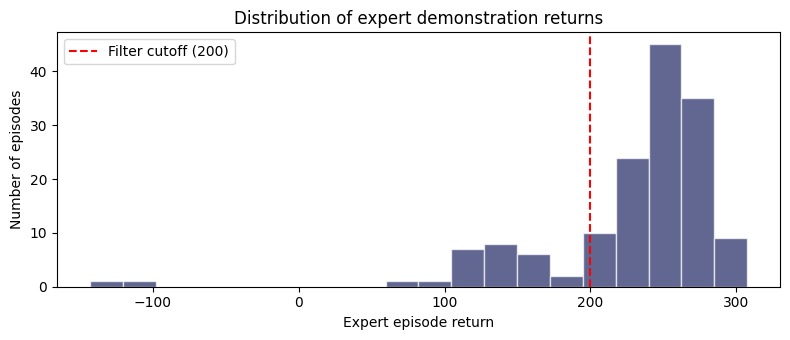

In [14]:
good_episodes = np.where(demo_returns >= cfg.DEMO_MIN_RETURN)[0]
print(f"Episodes with reward >= {cfg.DEMO_MIN_RETURN:.0f}: "
      f"{len(good_episodes)} / {cfg.DEMO_EPISODES}")

mask = np.isin(demo_ep_ids, good_episodes)
good_states = demo_states[mask]
good_actions = demo_actions[mask]

print(f"Transitions before filter: {len(demo_states):,}")
print(f"Transitions after filter:  {len(good_states):,}")

# Quick reward distribution
plt.figure(figsize=(8, 3.5))
plt.hist(demo_returns, bins=20, color="#1E2761", alpha=0.7, edgecolor="white")
plt.axvline(cfg.DEMO_MIN_RETURN, color="red", linestyle="--", label=f"Filter cutoff ({cfg.DEMO_MIN_RETURN:.0f})")
plt.xlabel("Expert episode return")
plt.ylabel("Number of episodes")
plt.title("Distribution of expert demonstration returns")
plt.legend()
plt.tight_layout()
plt.show()


---
#### **Phase 3 — Imitation Learning by Behavioral Cloning student**
---

A fresh MLP `π_θ(s) → logits over actions`, trained with cross-entropy on `(states, actions)`. No reward, no environment — pure supervised learning.


In [15]:
class BCPolicy(nn.Module):
    """Classifier mapping state -> logits over discrete actions."""
    def __init__(self, state_dim, n_actions, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, state):
        return self.net(state)

    def predict_action(self, state_np):
        state_t = torch.tensor(state_np, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            logits = self.forward(state_t)
        return int(logits.argmax(dim=1).item())


In [16]:
def train_bc(states_np, actions_np, cfg, verbose=True):
    """Train a behavioral cloning policy. Returns the trained model and loss/acc history."""
    n = len(states_np)
    perm = np.random.permutation(n)
    n_val = int(n * cfg.BC_VAL_FRACTION)
    val_idx = perm[:n_val]
    train_idx = perm[n_val:]

    X_train = torch.tensor(states_np[train_idx], dtype=torch.float32, device=device)
    y_train = torch.tensor(actions_np[train_idx], dtype=torch.long,   device=device)
    X_val   = torch.tensor(states_np[val_idx],   dtype=torch.float32, device=device)
    y_val   = torch.tensor(actions_np[val_idx],   dtype=torch.long,   device=device)

    model = BCPolicy(state_dim, n_actions, cfg.BC_HIDDEN_DIM).to(device)
    opt = optim.Adam(model.parameters(), lr=cfg.BC_LR)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    n_train = len(X_train)
    for epoch in range(1, cfg.BC_EPOCHS + 1):
        model.train()
        order = torch.randperm(n_train, device=device)
        running = 0.0
        n_batches = 0
        for start in range(0, n_train, cfg.BC_BATCH_SIZE):
            idx = order[start:start + cfg.BC_BATCH_SIZE]
            xb, yb = X_train[idx], y_train[idx]

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += loss.item()
            n_batches += 1
        train_loss = running / n_batches

        # Validation
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = F.cross_entropy(val_logits, y_val).item()
            val_acc = (val_logits.argmax(dim=1) == y_val).float().mean().item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"  Epoch {epoch:3d}/{cfg.BC_EPOCHS} | "
                  f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    return model, history


In [17]:
%%time
print("Training BC student from scratch on filtered expert demonstrations...")
student, history = train_bc(good_states, good_actions, cfg)


Training BC student from scratch on filtered expert demonstrations...
  Epoch   1/60 | train_loss=1.0341 | val_loss=0.8906 | val_acc=0.6513
  Epoch   5/60 | train_loss=0.6904 | val_loss=0.7138 | val_acc=0.7126
  Epoch  10/60 | train_loss=0.5599 | val_loss=0.5614 | val_acc=0.7655
  Epoch  15/60 | train_loss=0.4802 | val_loss=0.5102 | val_acc=0.7958
  Epoch  20/60 | train_loss=0.4345 | val_loss=0.4493 | val_acc=0.8134
  Epoch  25/60 | train_loss=0.3984 | val_loss=0.4287 | val_acc=0.8369
  Epoch  30/60 | train_loss=0.3794 | val_loss=0.3955 | val_acc=0.8435
  Epoch  35/60 | train_loss=0.3559 | val_loss=0.3859 | val_acc=0.8432
  Epoch  40/60 | train_loss=0.3407 | val_loss=0.3705 | val_acc=0.8539
  Epoch  45/60 | train_loss=0.3280 | val_loss=0.3549 | val_acc=0.8604
  Epoch  50/60 | train_loss=0.3190 | val_loss=0.3504 | val_acc=0.8626
  Epoch  55/60 | train_loss=0.2971 | val_loss=0.3330 | val_acc=0.8681
  Epoch  60/60 | train_loss=0.2877 | val_loss=0.3503 | val_acc=0.8577
CPU times: user 14.1

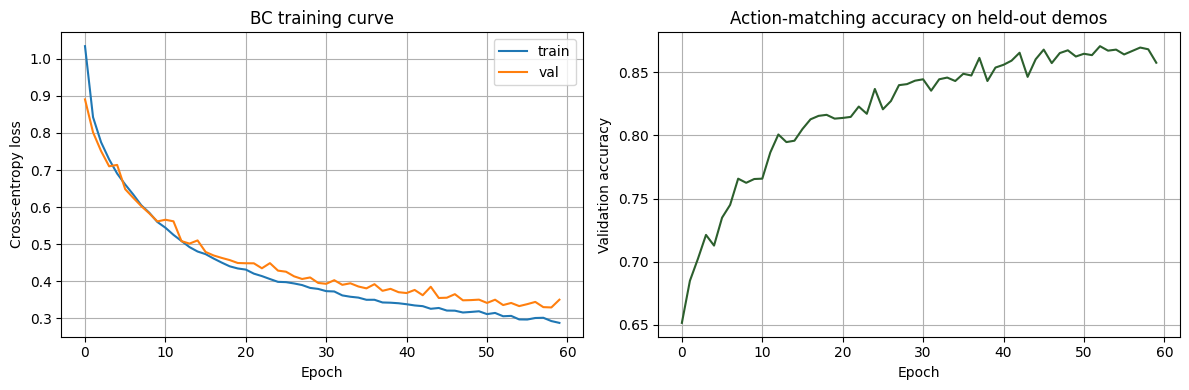

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("BC training curve")
axes[0].grid(True); axes[0].legend()

axes[1].plot(history["val_acc"], color="#2C5F2D")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Action-matching accuracy on held-out demos")
axes[1].grid(True)

plt.tight_layout()
plt.show()


---
#### **Phase 4 — Evaluate the student in the real environment**
---

Validation accuracy on held-out states only measures imitation. The real test is whether the student lands.


In [19]:
student_mean, student_std = evaluate_policy_fn(
    student.predict_action, eval_env, episodes=20
)
print(f"Student greedy evaluation over 20 episodes: {student_mean:.2f} ± {student_std:.2f}")
if student_mean >= cfg.SOLVED_REWARD:
    print(f"\n   Student crossed the {cfg.SOLVED_REWARD:.0f} threshold via Behavioral Cloning.")
else:
    print(f"\n   Below the {cfg.SOLVED_REWARD:.0f} threshold by {cfg.SOLVED_REWARD - student_mean:.1f} "
          f"points. Try more DEMO_EPISODES or more BC_EPOCHS.")


Student greedy evaluation over 20 episodes: 242.89 ± 46.71

   Student crossed the 200 threshold via Behavioral Cloning.


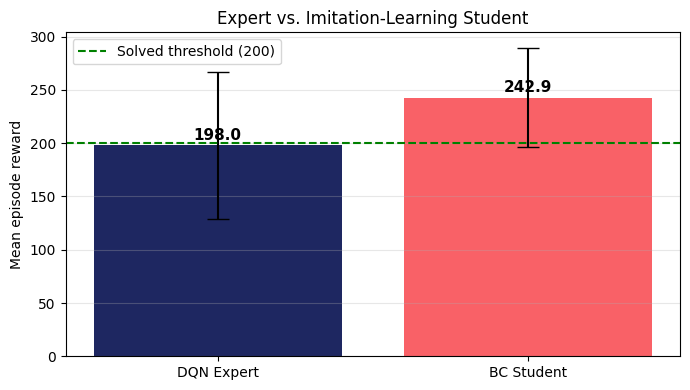

In [20]:
# Bar chart comparing expert vs. student
labels = ["DQN Expert", "BC Student"]
means = [expert_mean, student_mean]
stds = [expert_std, student_std]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, means, yerr=stds, capsize=8,
               color=["#1E2761", "#F96167"])
plt.axhline(cfg.SOLVED_REWARD, color="green", linestyle="--", label="Solved threshold (200)")
plt.ylabel("Mean episode reward")
plt.title("Expert vs. Imitation-Learning Student")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
for bar, m in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width() / 2, m + 5, f"{m:.1f}",
             ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


#### **Question: How does dataset size affect the student? - See some ablation results**

Optional: subsample the demonstration database and see how performance scales with the number of expert transitions. This is the classic supervised-learning question applied to imitation learning.


In [21]:
%%time
# Train BC students on subsets of the FILTERED demos and evaluate each.
subset_fractions = [0.1, 0.25, 0.5, 1.0]
ablation_results = []

for frac in subset_fractions:
    n_keep = max(1, int(len(good_states) * frac))
    idx = np.random.RandomState(SEED).permutation(len(good_states))[:n_keep]
    sub_states = good_states[idx]
    sub_actions = good_actions[idx]

    print(f"\nFraction {frac:.2f}  ({n_keep:,} transitions):")
    sub_model, _ = train_bc(sub_states, sub_actions, cfg, verbose=False)
    m, sd = evaluate_policy_fn(sub_model.predict_action, eval_env, episodes=10)
    print(f"  Eval mean reward: {m:.2f} ± {sd:.2f}")
    ablation_results.append({"fraction": frac, "n": n_keep, "mean": m, "std": sd})

ablation_df = pd.DataFrame(ablation_results)
ablation_df



Fraction 0.10  (3,654 transitions):
  Eval mean reward: 224.26 ± 55.75

Fraction 0.25  (9,136 transitions):
  Eval mean reward: 230.39 ± 60.43

Fraction 0.50  (18,272 transitions):
  Eval mean reward: 202.82 ± 63.99

Fraction 1.00  (36,545 transitions):
  Eval mean reward: 251.14 ± 42.63
CPU times: user 12.3 s, sys: 292 ms, total: 12.6 s
Wall time: 15.3 s


,fraction,n,mean,std
0,0.10,3654,224.262847,55.752056
1,0.25,9136,230.391584,60.426925
2,0.50,18272,202.815532,63.994999
3,1.00,36545,251.137021,42.629927


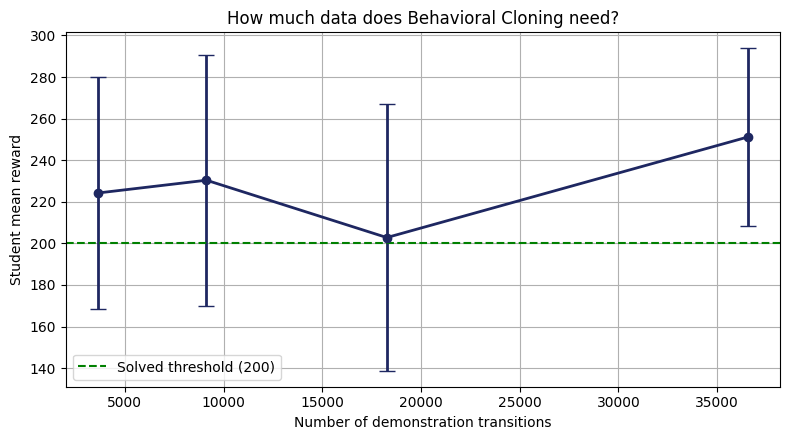

In [22]:
plt.figure(figsize=(8, 4.5))
plt.errorbar(ablation_df["n"], ablation_df["mean"], yerr=ablation_df["std"],
             fmt="o-", capsize=6, linewidth=2, color="#1E2761")
plt.axhline(cfg.SOLVED_REWARD, color="green", linestyle="--", label="Solved threshold (200)")
plt.xlabel("Number of demonstration transitions")
plt.ylabel("Student mean reward")
plt.title("How much data does Behavioral Cloning need?")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### **Render an episode of the student**


Student episode reward: 199.80 over 734 frames
Saved GIF: ./LunarLander_BC_Student.gif


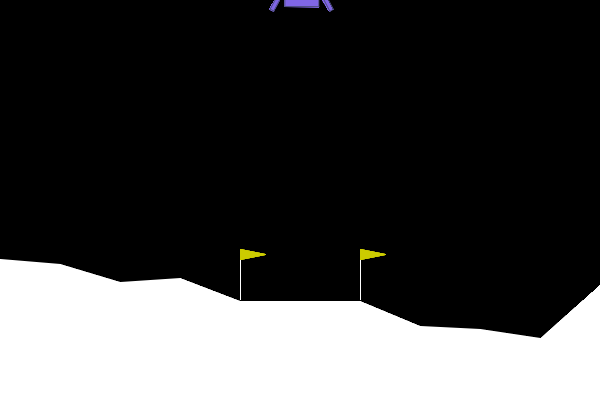

In [28]:
import os
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", os.environ["MUJOCO_GL"])

from PIL import Image
from IPython.display import Image as IPyImage, display

render_env = gym.make(cfg.ENV_NAME, render_mode="rgb_array")
frames = []

state, _ = render_env.reset(seed=SEED)
total_reward = 0.0

for step in range(cfg.MAX_STEPS):
    action = student.predict_action(state)
    next_state, reward, terminated, truncated, _ = render_env.step(action)
    frames.append(render_env.render())
    total_reward += reward
    state = next_state
    if terminated or truncated:
        break

render_env.close()
print(f"Student episode reward: {total_reward:.2f} over {len(frames)} frames")

gif_path = "./LunarLander_BC_Student.gif"
images = [Image.fromarray(f) for f in frames]
images[0].save(gif_path, save_all=True, append_images=images[1:], duration=40, loop=0)
print(f"Saved GIF: {gif_path}")
display(IPyImage(filename=gif_path))


## 9. Discussion

What happened, and why:

1. **The expert provides clean labels.** Because we collect demos by running the *greedy* DQN policy, every action in the dataset is the expert's best guess. There's no noise from epsilon-greedy exploration.
2. **Filtering out failed demos was critical.** Even a solved DQN occasionally crashes. Behavioral Cloning has no way to tell good actions from bad — it just imitates. Throwing away crash trajectories before training removed a lot of noise.
3. **Cross-entropy supervises one classification per state.** Discrete action spaces are friendly to imitation — no need to fit Gaussian heads or worry about ranges.
4. **Distribution shift is real but tolerable here.** LunarLander episodes are short, the dynamics are smooth, and the expert visits a relatively narrow region of state space. So Behavioral Cloning works without falling back to DAgger.
5. **Action-class imbalance matters.** The expert often picks `NOOP` (action 0) — see the action histogram above. If you find the student stalls, weighting the cross-entropy loss by the inverse class frequency can help.

If the student fails to reach 200, try in order:
- Increase `DEMO_EPISODES` (more diverse demos).
- Lower the `DEMO_MIN_RETURN` cutoff if it removed too much data — or raise it if there's still noise.
- Increase `BC_EPOCHS` and/or shrink `BC_LR`.
- Add class-balanced cross-entropy weights.
- Implement **DAgger**: roll out the student, ask the expert to label its visited states, append, retrain. The student then sees its own failure-mode states with the right labels.
